In [18]:
import numpy as np
import matplotlib.pyplot as plt
import sys, os
from PIL import Image
import pickle

##　3.2 活性化関数

In [19]:
## 3.2.2 ステップ関数の実装
def step_function_pre(x):
    if x > 0:
        return 1
    else:
        return 0

def step_function(x):
    y = x > 0
    return y.astype(np.int)

x = np.array([-1.0, 1.0, 2.0])
print(x)
y = x > 0
print(y)
y = y.astype(int)
print(y)


[-1.  1.  2.]
[False  True  True]
[0 1 1]


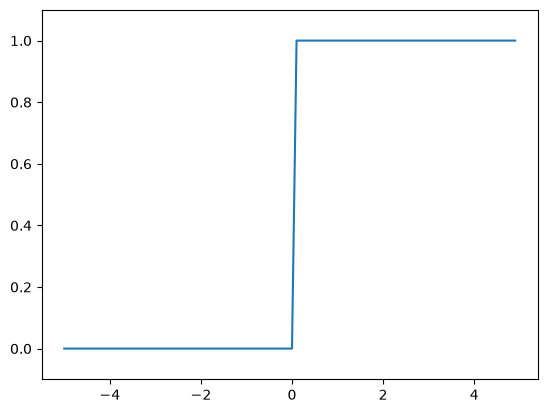

In [20]:
## 3.2.3 ステップ関数のグラフ
def step_function(x):
    return np.array(x>0, dtype=int)

x = np.arange(-5.0, 5.0, 0.1)
y = step_function(x)
plt.plot(x, y)
plt.ylim(-0.1, 1.1)
plt.show()

[0.26894142 0.73105858 0.88079708]
[2. 3. 4.]
[1.         0.5        0.33333333]


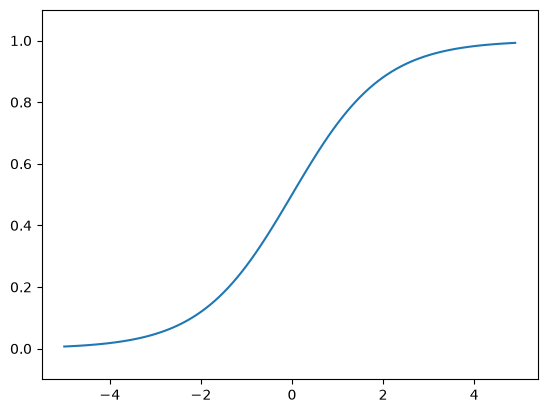

In [21]:
## 3.2.4 シグモイド関数の実装
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

x = np.array([-1.0, 1.0, 2.0])
print(sigmoid(x))

t = np.array([1.0, 2.0, 3.0])
print(1.0 + t)
print(1.0 / t)

x = np.arange(-5.0, 5.0, 0.1)
y = sigmoid(x)
plt.plot(x, y)
plt.ylim(-0.1, 1.1)
plt.show()


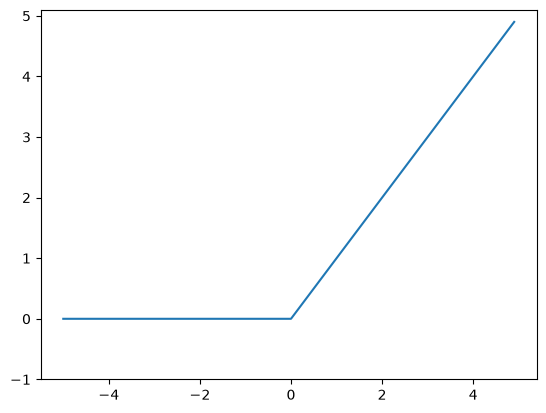

In [22]:
## 3.2.7 ReLU関数
def relu(x):
    return np.maximum(0, x)

x = np.arange(-5.0, 5.0, 0.1)
y = relu(x)
plt.plot(x, y)
plt.ylim(-1.0, 5.1)
plt.show()

## 3.3 多次元配列の計算

In [23]:
## 3.3.1 多次元配列
A = np.array([1, 2, 3, 4])
print(A)
print(np.ndim(A))
print(A.shape)
print(A.shape[0])

B = np.array([[1, 2], [3, 4], [5, 6]])
print(B)
print(np.ndim(B))
print(B.shape)

[1 2 3 4]
1
(4,)
4
[[1 2]
 [3 4]
 [5 6]]
2
(3, 2)


In [24]:
## 3.3.2 行列の積
A = np.array([[1, 2], [3, 4]])
print(A.shape)
B = np.array([[5, 6], [7, 8]])
print(B.shape)
print(np.dot(A, B))

A = np.array([[1, 2, 3], [4, 5, 6]])
print(A.shape)
B = np.array([[1, 2], [3, 4], [5, 6]])
print(B.shape)
print(np.dot(A, B))

C = np.array([[1, 2], [3, 4]])
print(C.shape)
print(A.shape)
# print(np.dot(A, C))

A = np.array([[1, 2], [3, 4], [5, 6]])
print(A.shape)
B = np.array([7, 8])
print(B.shape)
print(np.dot(A, B))

(2, 2)
(2, 2)
[[19 22]
 [43 50]]
(2, 3)
(3, 2)
[[22 28]
 [49 64]]
(2, 2)
(2, 3)
(3, 2)
(2,)
[23 53 83]


In [25]:
## 3.3.3 ニューラルネットワークの行列の積
X = np.array([1, 2])
print(X.shape)
W = np.array([[1, 3, 5], [2, 4, 6]])
print(W)
print(W.shape)
Y = np.dot(X, W)
print(Y)

(2,)
[[1 3 5]
 [2 4 6]]
(2, 3)
[ 5 11 17]


## 3.4 3層ニューラルネットワークの実装

In [26]:
## 3.4.2 各層における信号伝達の実装
X = np.array([1.0, 0.5])
W1 = np.array([[0.1, 0.3, 0.5], [0.2, 0.4, 0.6]])
B1 = np.array([0.1, 0.2, 0.3])

print(X.shape)
print(W1.shape)
print(B1.shape)

A1 = np.dot(X, W1) + B1
Z1 = sigmoid(A1)
print(A1)
print(Z1)

W2 = np.array([[0.1, 0.4], [0.2, 0.5], [0.3, 0.6]])
B2 = np.array([0.1, 0.2])

print(Z1.shape)
print(W2.shape)
print(B2.shape)

A2 = np.dot(Z1, W2) + B2
Z2 = sigmoid(A2)
print(A2)
print(Z2)

def indentity_function(x):
    return x

W3 = np.array([[0.1, 0.3], [0.2, 0.4]])
B3 = np.array([0.1, 0.2])

A3 = np.dot(Z2, W3) + B3
Y = indentity_function(A3)
print(Y)

(2,)
(2, 3)
(3,)
[0.3 0.7 1.1]
[0.57444252 0.66818777 0.75026011]
(3,)
(3, 2)
(2,)
[0.51615984 1.21402696]
[0.62624937 0.7710107 ]
[0.31682708 0.69627909]


In [27]:
## 3.4.3. 実装のまとめ
def init_network():
    network = {}
    network['W1'] = np.array([[0.1, 0.3, 0.5], [0.2, 0.4, 0.6]])
    network['b1'] = np.array([0.1, 0.2, 0.3])
    network['W2'] = np.array([[0.1, 0.4], [0.2, 0.5], [0.3, 0.6]])
    network['b2'] = np.array([0.1, 0.2])
    network['W3'] = np.array([[0.1, 0.3], [0.2, 0.4]])
    network["b3"] = np.array([0.1, 0.2])
    
    return network

def forward(newtwork, x):
    W1, W2, W3 = newtwork['W1'], newtwork['W2'], newtwork["W3"]
    b1, b2, b3 = newtwork['b1'], newtwork['b2'], newtwork['b3']
    
    a1 = np.dot(x, W1) + b1
    z1 = sigmoid(a1)
    a2 = np.dot(z1, W2) + b2
    z2 = sigmoid(a2)
    a3 = np.dot(z2, W3) + b3
    y = indentity_function(a3)
    
    return y

newtwork = init_network()
x = np.array([1.0, 0.5])
y = forward(newtwork, x)
print(y)    

[0.31682708 0.69627909]


## 3.5 出力層の設計

In [28]:
## 3.5.1 高等関数とソフトマックス関数
a = np.array([0.3, 2.9, 4.0])
exp_a = np.exp(a)
print(exp_a)
sum_exp_a = np.sum(exp_a)
y = exp_a / sum_exp_a
print(y)

def softmax(a):
    exp_a = np.exp(a)
    sum_exp_a = np.sum(exp_a)
    y = exp_a / sum_exp_a
    
    return y

[ 1.34985881 18.17414537 54.59815003]
[0.01821127 0.24519181 0.73659691]


In [29]:
## 3.5.2 ソフトマックス関数の実装上の注意
a = np.array([1010, 1000, 990])
print(np.exp(a) / np.sum(np.exp(a)) )

c = np.max(a)
print(a - c)
print(np.exp(a - c) / np.sum(np.exp(a - c)))

def softmax(a):
    c = np.max(a)
    exp_a = np.exp(a - c)
    sum_exp_a = np.sum(exp_a)
    y = exp_a / sum_exp_a
    
    return y

[nan nan nan]
[  0 -10 -20]
[9.99954600e-01 4.53978686e-05 2.06106005e-09]


/var/folders/h_/0sc1v0715n90mc539lpr7p_w0000gn/T/ipykernel_15084/938256540.py:3: RuntimeWarning: overflow encountered in exp
  print(np.exp(a) / np.sum(np.exp(a)) )
/var/folders/h_/0sc1v0715n90mc539lpr7p_w0000gn/T/ipykernel_15084/938256540.py:3: RuntimeWarning: invalid value encountered in divide
  print(np.exp(a) / np.sum(np.exp(a)) )


In [30]:
## 3.5.3 ソフトマックス関数の特徴
a = np.array([0.3, 2.9, 4.0])
y = softmax(a)
print(y)
print(np.sum(y))

[0.01821127 0.24519181 0.73659691]
1.0


## 3.6. 手書き数字認識

In [31]:
## 3.6.1 MNISTデータセット
sys.path.append(os.pardir)
from dataset.mnist import load_mnist

(x_train, t_train), (x_test, t_test) = load_mnist(flatten=True, normalize=False)
print(x_train.shape)
print(t_train.shape)
print(x_test.shape)
print(t_test.shape)

(60000, 784)
(60000,)
(10000, 784)
(10000,)


In [32]:
def img_show(img):
    pil_img = Image.fromarray(np.uint8(img))
    pil_img.show()

img = x_train[0]
label = t_train[0]
print(label)
print(img.shape)
img = img.reshape(28, 28)
print(img.shape)
img_show(img)


5
(784,)
(28, 28)


In [34]:
## 3.6.2 ニューラルネットワークの推論処理
def get_data():
    (x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, flatten=True, one_hot_label= False)
    return x_test, t_test

def init_network():
    with open("../dataset/sample_weight.pkl", 'rb') as f:
        newtwork = pickle.load(f)
    return newtwork

def predict(network, x):
    W1, W2, W3 = newtwork['W1'], newtwork["W2"], newtwork["W3"]
    b1, b2, b3 = newtwork['b1'], newtwork['b2'], newtwork['b3']

    a1 = np.dot(x, W1) + b1
    z1 = sigmoid(a1)
    a2 = np.dot(z1, W2) + b2
    z2 = sigmoid(a2)
    a3 = np.dot(z2, W3) + b3
    y = softmax(a3)

    return y

x, t = get_data()
newtwork = init_network()

accuracy_cut = 0
for i in range(len(x)):
    y = predict(newtwork, x[i])
    p = np.argmax(y)

    if p == t[i]:
        accuracy_cut += 1
print("Accuracy: " + str(float(accuracy_cut)/len(x)))




Accuracy: 0.9352


In [36]:
## 3.6.3 バッチ処理
x, _ = get_data()
newtwork = init_network()
W1, W2, W3 = newtwork['W1'], newtwork['W2'], newtwork["W3"]
print(x.shape)
print(x[0].shape)
print(W1.shape)
print(W2.shape)
print(W3.shape)

(10000, 784)
(784,)
(784, 50)
(50, 100)
(100, 10)


In [38]:
x, t = get_data()
newtwork = init_network()

batch_size = 100
accuracy_cut = 0

for i in range(0, len(x), batch_size):
    x_batch = x[i: i+batch_size]
    y_batch = predict(newtwork, x_batch)
    p = np.argmax(y_batch, axis=1)
    accuracy_cut += np.sum(p == t[i: i+batch_size])

print("ACCURACY: " + str(float(accuracy_cut)/ len(x)))

ACCURACY: 0.9352
